In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("ai_jobs_global.csv")

In [4]:
df.shape

(5773, 13)

In [5]:
df.columns

Index(['job_title', 'company', 'country', 'city', 'salary_min', 'salary_max',
       'currency', 'remote_type', 'experience_level', 'required_skills',
       'posted_date', 'source', 'job_description'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5773 entries, 0 to 5772
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_title         5773 non-null   str    
 1   company           5768 non-null   str    
 2   country           5773 non-null   str    
 3   city              5773 non-null   str    
 4   salary_min        3343 non-null   float64
 5   salary_max        3358 non-null   float64
 6   currency          5773 non-null   str    
 7   remote_type       5773 non-null   str    
 8   experience_level  5773 non-null   str    
 9   required_skills   1084 non-null   str    
 10  posted_date       5650 non-null   str    
 11  source            5773 non-null   str    
 12  job_description   5773 non-null   str    
dtypes: float64(2), str(11)
memory usage: 338.3 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

job_title              0
company                5
country                0
city                   0
salary_min          2430
salary_max          2415
currency               0
remote_type            0
experience_level       0
required_skills     4689
posted_date          123
source                 0
job_description        0
dtype: int64

In [9]:
df["company"] = df["company"].fillna("Unknown")

In [10]:
df["company"].isnull().sum()

np.int64(0)

In [12]:


df["currency"].unique()


<StringArray>
['USD']
Length: 1, dtype: str

In [13]:
df["remote_type"].unique()
df["experience_level"].unique()
df["country"].nunique()
df["job_title"].nunique()

2883

In [14]:
text_columns = [
    "job_title",
    "company",
    "country",
    "city",
    "currency",
    "remote_type",
    "experience_level",
    "source"
]

for col in text_columns:
    df[col] = df[col].str.strip()

In [15]:
df["required_skills"].head(10)

0                             RAG
1                             RAG
2                             RAG
3                             NaN
4                             NaN
5    Python, NLP, Computer Vision
6    Python, NLP, Computer Vision
7    Python, NLP, Computer Vision
8               Python, LangChain
9                             NaN
Name: required_skills, dtype: str

In [16]:
df["required_skills"] = df["required_skills"].astype("string")


In [17]:
df["required_skills"] = df["required_skills"].astype("string")

In [19]:
df["posted_date"] = pd.to_datetime(
    df["posted_date"],
    dayfirst=True,
    errors="coerce"
)

In [20]:
df["posted_date"].dtype

dtype('<M8[us]')

In [21]:
df["posted_date"].dtype

dtype('<M8[us]')

In [22]:
df["posted_date"].isnull().sum()

np.int64(123)

In [23]:
df[["salary_min", "salary_max"]].dtypes

salary_min    float64
salary_max    float64
dtype: object

In [24]:
df[["salary_min", "salary_max"]].describe()

,salary_min,salary_max
count,3343.000000,3358.000000
mean,109240.801675,120957.415128
std,46680.622714,58922.331934
min,0.000000,0.000000
25%,77000.000000,82000.000000
50%,99000.000000,108000.000000
75%,133000.000000,148000.000000
max,413000.000000,800000.000000


In [25]:
(df["salary_min"] > df["salary_max"]).sum()

np.int64(4)

In [26]:
df.loc[
    df["salary_min"] > df["salary_max"],
    ["job_title", "company", "salary_min", "salary_max", "currency"]
]

,job_title,company,salary_min,salary_max,currency
2945,Senior AI Engineer,Apollo.io,160000.0,18000.0,USD
3585,Finnish Language Specialist - Freelance AI Tra...,Invisible Agency,148000.0,100000.0,USD
3586,Ukrainian Language Specialist - Freelance AI T...,Invisible Agency,148000.0,100000.0,USD
3589,Persian Language Specialist - Freelance AI Tra...,Invisible Agency,148000.0,100000.0,USD


In [27]:
df["invalid_salary"] = (
    (df["salary_min"] > df["salary_max"]) |
    (df["salary_min"] < 0) |
    (df["salary_max"] < 0)
)

In [28]:
df["invalid_salary"].value_counts()

invalid_salary
False    5769
True        4
Name: count, dtype: int64

In [29]:
salary_df = df[
    df["salary_min"].notna() &
    df["salary_max"].notna() &
    ~df["invalid_salary"]
].copy()

In [30]:
salary_df.shape

(3335, 14)

In [31]:
salary_df["avg_salary"] = (
    salary_df["salary_min"] +
    salary_df["salary_max"]
) / 2

In [32]:
salary_df["avg_salary"].describe()

count      3335.000000
mean     114851.124438
std       50770.492133
min           0.000000
25%       81000.000000
50%      103000.000000
75%      141000.000000
max      565000.000000
Name: avg_salary, dtype: float64

In [33]:
(
    salary_df["avg_salary"] < salary_df["salary_min"]
).sum()

np.int64(0)

In [34]:
(
    salary_df["avg_salary"] > salary_df["salary_max"]
).sum()

np.int64(0)

In [35]:
skill_df = salary_df[
    salary_df["required_skills"].notna()
].copy()

skill_df["skill"] = skill_df["required_skills"].str.split(",")

In [36]:
skill_df = skill_df.explode("skill")

In [37]:
skill_df["skill"] = skill_df["skill"].str.strip().str.lower()

In [39]:
skill_df["skill"].head(20)

0                 rag
1                 rag
2                 rag
5              python
5                 nlp
5     computer vision
6              python
6                 nlp
6     computer vision
7              python
7                 nlp
7     computer vision
8              python
8           langchain
14                aws
15             python
15                sql
15                rag
16          langchain
16                rag
Name: skill, dtype: str

In [40]:
skill_demand = (
    skill_df["skill"]
    .value_counts()
    .reset_index()
)

skill_demand.columns = [
    "skill",
    "job_postings"
]

In [41]:
skill_demand.head()

,skill,job_postings
0,computer vision,221
1,python,209
2,nlp,143
3,azure,83
4,sql,65


In [42]:
skill_demand_filtered = skill_demand[
    skill_demand["job_postings"] >= 10
].copy()

In [43]:
skill_salary = (
    skill_df
    .groupby("skill")["avg_salary"]
    .agg(["mean", "count"])
    .reset_index()
)

In [44]:
skill_salary.columns = [
    "skill",
    "avg_salary",
    "salary_job_count"
]

In [45]:
skill_salary = skill_salary[
    skill_salary["salary_job_count"] >= 10
].copy()

In [46]:
overall_avg_salary = salary_df["avg_salary"].mean()

overall_avg_salary

np.float64(114851.12443778111)

In [47]:
skill_salary["salary_premium"] = (
    skill_salary["avg_salary"] -
    overall_avg_salary
)

In [48]:
skill_salary["premium_pct"] = (
    skill_salary["salary_premium"] /
    overall_avg_salary
) * 100

In [49]:
skill_analysis = skill_demand_filtered.merge(
    skill_salary[
        [
            "skill",
            "avg_salary",
            "salary_premium",
            "premium_pct",
            "salary_job_count"
        ]
    ],
    on="skill",
    how="inner"
)

In [50]:
skill_analysis.sort_values(
    "job_postings",
    ascending=False
).head(15)

,skill,job_postings,avg_salary,salary_premium,premium_pct,salary_job_count
0,computer vision,221,136432.126697,21581.002259,18.790414,221
1,python,209,104667.464115,-10183.660323,-8.866836,209
2,nlp,143,119377.622378,4526.497940,3.941187,143
3,azure,83,98837.349398,-16013.775040,-13.943072,83
4,sql,65,114238.461538,-612.662899,-0.533441,65
5,rag,57,111228.070175,-3623.054262,-3.154566,57
6,aws,56,111607.142857,-3243.981581,-2.824510,56
7,r,53,120952.830189,6101.705751,5.312709,53
8,openai,46,85141.304348,-29709.820090,-25.868114,46
9,fine-tuning,24,116645.833333,1794.708896,1.562639,24


In [51]:
demand_threshold = skill_analysis["job_postings"].median()

In [52]:
premium_threshold=0

In [55]:
skill_analysis["skill_category"] = np.select(
    [
        (skill_analysis["job_postings"] >= demand_threshold) &
        (skill_analysis["premium_pct"] > premium_threshold),

        (skill_analysis["job_postings"] >= demand_threshold) &
        (skill_analysis["premium_pct"] <= premium_threshold),

        (skill_analysis["job_postings"] < demand_threshold) &
        (skill_analysis["premium_pct"] > premium_threshold)
    ],
    [
        "High Demand + Premium",
        "High Demand + No Premium",
        "Low Demand + Premium"
    ],
    default="Low Demand + No Premium"
)

In [57]:
skill_analysis.head(20)


,skill,job_postings,avg_salary,salary_premium,premium_pct,salary_job_count,skill_category
0,computer vision,221,136432.126697,21581.002259,18.790414,221,High Demand + Premium
1,python,209,104667.464115,-10183.660323,-8.866836,209,High Demand + No Premium
2,nlp,143,119377.622378,4526.497940,3.941187,143,High Demand + Premium
3,azure,83,98837.349398,-16013.775040,-13.943072,83,High Demand + No Premium
4,sql,65,114238.461538,-612.662899,-0.533441,65,High Demand + No Premium
5,rag,57,111228.070175,-3623.054262,-3.154566,57,High Demand + No Premium
6,aws,56,111607.142857,-3243.981581,-2.824510,56,High Demand + No Premium
7,r,53,120952.830189,6101.705751,5.312709,53,High Demand + Premium
8,openai,46,85141.304348,-29709.820090,-25.868114,46,Low Demand + No Premium
9,fine-tuning,24,116645.833333,1794.708896,1.562639,24,Low Demand + Premium


In [58]:
top_premium_skills = (
    skill_analysis
    .sort_values("premium_pct", ascending=False)
    .head(10)
)

In [59]:
top_premium_skills

,skill,job_postings,avg_salary,salary_premium,premium_pct,salary_job_count,skill_category
14,transformers,11,184954.545455,70103.421017,61.038515,11,Low Demand + Premium
0,computer vision,221,136432.126697,21581.002259,18.790414,221,High Demand + Premium
13,langchain,11,128090.909091,13239.784653,11.527780,11,Low Demand + Premium
7,r,53,120952.830189,6101.705751,5.312709,53,High Demand + Premium
2,nlp,143,119377.622378,4526.497940,3.941187,143,High Demand + Premium
12,spark,12,117458.333333,2607.208896,2.270077,12,Low Demand + Premium
9,fine-tuning,24,116645.833333,1794.708896,1.562639,24,Low Demand + Premium
4,sql,65,114238.461538,-612.662899,-0.533441,65,High Demand + No Premium
6,aws,56,111607.142857,-3243.981581,-2.824510,56,High Demand + No Premium
5,rag,57,111228.070175,-3623.054262,-3.154566,57,High Demand + No Premium


In [60]:
top_demand_skills = (
    skill_analysis
    .sort_values("job_postings", ascending=False)
    .head(10)
)

In [61]:
top_demand_skills

,skill,job_postings,avg_salary,salary_premium,premium_pct,salary_job_count,skill_category
0,computer vision,221,136432.126697,21581.002259,18.790414,221,High Demand + Premium
1,python,209,104667.464115,-10183.660323,-8.866836,209,High Demand + No Premium
2,nlp,143,119377.622378,4526.497940,3.941187,143,High Demand + Premium
3,azure,83,98837.349398,-16013.775040,-13.943072,83,High Demand + No Premium
4,sql,65,114238.461538,-612.662899,-0.533441,65,High Demand + No Premium
5,rag,57,111228.070175,-3623.054262,-3.154566,57,High Demand + No Premium
6,aws,56,111607.142857,-3243.981581,-2.824510,56,High Demand + No Premium
7,r,53,120952.830189,6101.705751,5.312709,53,High Demand + Premium
8,openai,46,85141.304348,-29709.820090,-25.868114,46,Low Demand + No Premium
9,fine-tuning,24,116645.833333,1794.708896,1.562639,24,Low Demand + Premium


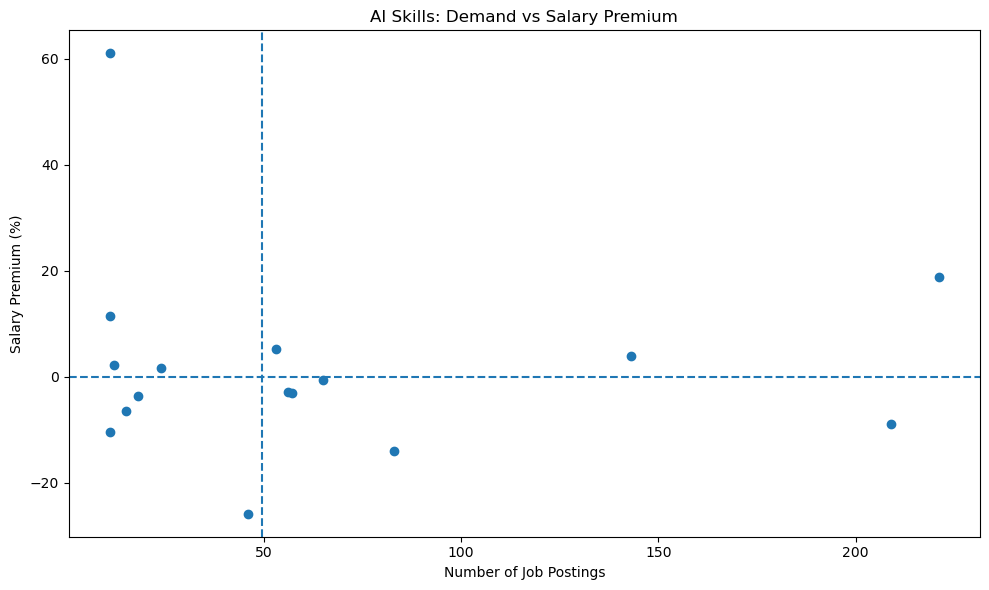

In [62]:
plt.figure(figsize=(10, 6))

plt.scatter(
    skill_analysis["job_postings"],
    skill_analysis["premium_pct"]
)

plt.axhline(0, linestyle="--")
plt.axvline(demand_threshold, linestyle="--")

plt.xlabel("Number of Job Postings")
plt.ylabel("Salary Premium (%)")
plt.title("AI Skills: Demand vs Salary Premium")

plt.tight_layout()
plt.show()

In [63]:
role_demand = (
    df.groupby("job_title")
      .size()
      .reset_index(name="job_postings")
      .sort_values(
          "job_postings",
          ascending=False
      )
)

In [64]:
role_demand.head(15)

,job_title,job_postings
778,Data Scientist,281
102,AI Engineer,270
1495,Machine Learning Engineer (PhD Intern),173
1487,Machine Learning Engineer,110
2112,Senior Data Scientist,105
1158,Generative AI Automation Engineer - Remote Job,98
2267,Senior Machine Learning Engineer,71
1457,ML/LLM Operations Engineer,53
260,AI Research Scientist - Language - MRS AI,49
1575,Machine Learning Operations (MLOps) Intern,48


In [65]:
role_salary = (
    salary_df
    .groupby("job_title")["avg_salary"]
    .agg(["mean", "count"])
    .reset_index()
)

In [66]:
role_salary.columns = [
    "job_title",
    "avg_salary",
    "salary_job_count"
]

In [67]:
role_salary = role_salary[
    role_salary["salary_job_count"] >= 10
].copy()

In [68]:
role_analysis = role_demand.merge(
    role_salary,
    on="job_title",
    how="inner"
)

In [69]:
role_analysis_filtered = role_analysis[
    role_analysis["salary_job_count"] >= 10
].copy()

In [70]:
top_roles = (
    role_analysis_filtered
    .sort_values(
        "job_postings",
        ascending=False
    )
    .head(10)
)

In [71]:
top_roles

,job_title,job_postings,avg_salary,salary_job_count
0,Data Scientist,281,103605.855856,222
1,AI Engineer,270,113595.652174,230
2,Machine Learning Engineer (PhD Intern),173,87000.000000,173
3,Machine Learning Engineer,110,91420.000000,75
4,Senior Data Scientist,105,110202.702703,37
5,Generative AI Automation Engineer - Remote Job,98,114867.346939,98
6,Senior Machine Learning Engineer,71,99535.714286,42
7,ML/LLM Operations Engineer,53,105584.905660,53
8,AI Research Scientist - Language - MRS AI,49,114469.387755,49
9,Machine Learning Operations (MLOps) Intern,48,47822.916667,48


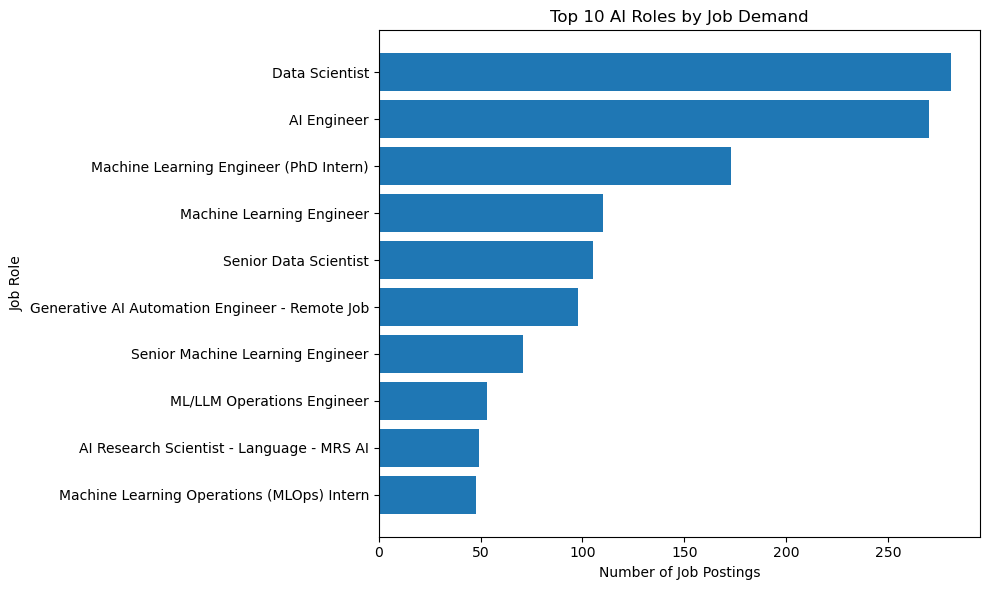

In [74]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_roles["job_title"],
    top_roles["job_postings"]
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Job Role")
plt.title("Top 10 AI Roles by Job Demand")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [75]:
country_demand = (
    df.groupby("country")
      .size()
      .reset_index(name="job_postings")
      .sort_values(
          "job_postings",
          ascending=False
      )
)

In [76]:
country_salary = (
    salary_df
    .groupby("country")["avg_salary"]
    .agg(["mean", "count"])
    .reset_index()
)

In [77]:
country_salary.columns = [
    "country",
    "avg_salary",
    "salary_job_count"
]

In [78]:
country_salary = country_salary[
    country_salary["salary_job_count"] >= 10
].copy()

In [79]:
country_analysis = country_demand.merge(
    country_salary,
    on="country",
    how="inner"
)

In [80]:
country_analysis_filtered = country_analysis[
    country_analysis["salary_job_count"] >= 10
].copy()

In [81]:
country_analysis_filtered = (
    country_analysis_filtered
    .sort_values(
        "job_postings",
        ascending=False
    )
)

In [82]:
country_analysis_filtered

,country,job_postings,avg_salary,salary_job_count
0,United States,1837,132464.893033,1823
1,United Kingdom,1185,91381.033023,1181
2,Canada,1068,105388.059701,201
3,Germany,944,88598.360656,61
4,Australia,739,101978.260870,69


In [83]:
top_countries = (
    country_analysis_filtered
    .sort_values(
        "job_postings",
        ascending=False
    )
    .head(10)
)

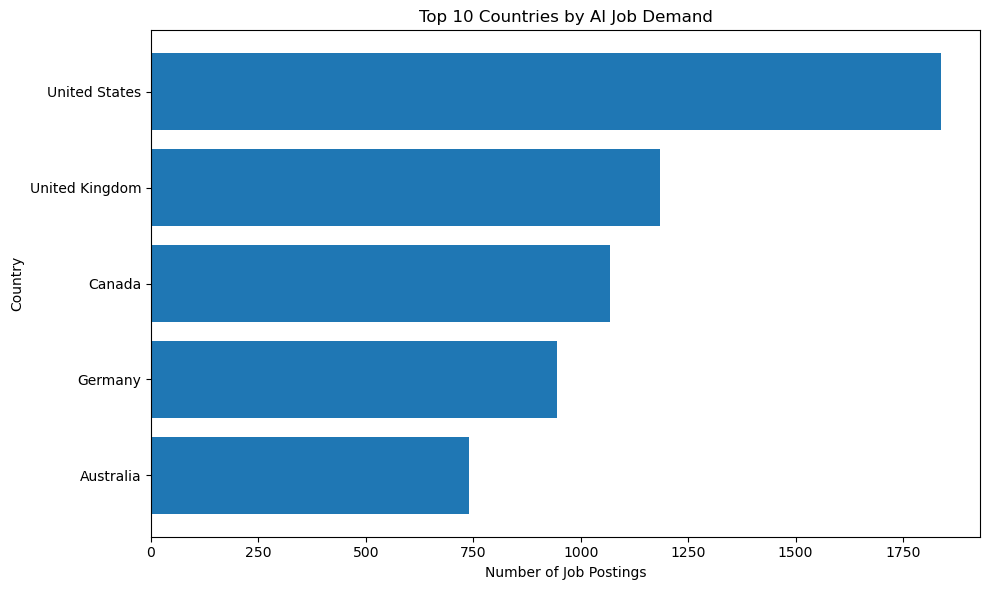

In [84]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["country"],
    top_countries["job_postings"]
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Country")
plt.title("Top 10 Countries by AI Job Demand")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

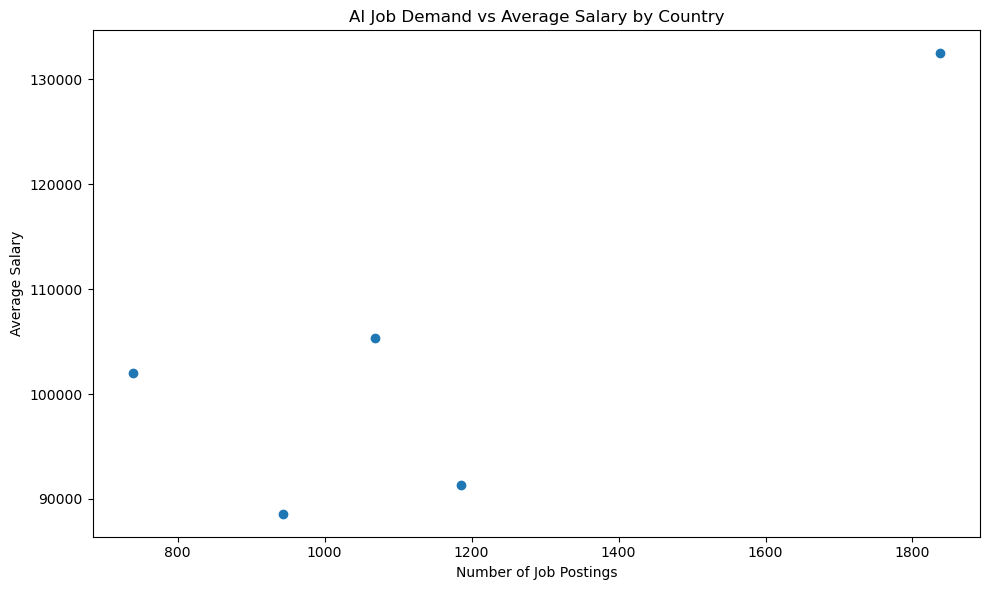

In [85]:
plt.figure(figsize=(10, 6))

plt.scatter(
    country_analysis_filtered["job_postings"],
    country_analysis_filtered["avg_salary"]
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Average Salary")
plt.title("AI Job Demand vs Average Salary by Country")

plt.tight_layout()
plt.show()

In [86]:
skill_final = (
    skill_analysis[
        [
            "skill",
            "job_postings",
            "avg_salary",
            "premium_pct",
            "skill_category"
        ]
    ]
    .sort_values(
        "job_postings",
        ascending=False
    )
)

In [87]:
skill_final

,skill,job_postings,avg_salary,premium_pct,skill_category
0,computer vision,221,136432.126697,18.790414,High Demand + Premium
1,python,209,104667.464115,-8.866836,High Demand + No Premium
2,nlp,143,119377.622378,3.941187,High Demand + Premium
3,azure,83,98837.349398,-13.943072,High Demand + No Premium
4,sql,65,114238.461538,-0.533441,High Demand + No Premium
5,rag,57,111228.070175,-3.154566,High Demand + No Premium
6,aws,56,111607.142857,-2.824510,High Demand + No Premium
7,r,53,120952.830189,5.312709,High Demand + Premium
8,openai,46,85141.304348,-25.868114,Low Demand + No Premium
9,fine-tuning,24,116645.833333,1.562639,Low Demand + Premium


In [88]:
role_final = (
    role_analysis_filtered[
        [
            "job_title",
            "job_postings",
            "avg_salary",
            "salary_job_count"
        ]
    ]
    .sort_values(
        "job_postings",
        ascending=False
    )
)

In [89]:
role_final.head(15)

,job_title,job_postings,avg_salary,salary_job_count
0,Data Scientist,281,103605.855856,222
1,AI Engineer,270,113595.652174,230
2,Machine Learning Engineer (PhD Intern),173,87000.000000,173
3,Machine Learning Engineer,110,91420.000000,75
4,Senior Data Scientist,105,110202.702703,37
5,Generative AI Automation Engineer - Remote Job,98,114867.346939,98
6,Senior Machine Learning Engineer,71,99535.714286,42
7,ML/LLM Operations Engineer,53,105584.905660,53
8,AI Research Scientist - Language - MRS AI,49,114469.387755,49
9,Machine Learning Operations (MLOps) Intern,48,47822.916667,48


In [90]:
country_final = (
    country_analysis_filtered[
        [
            "country",
            "job_postings",
            "avg_salary",
            "salary_job_count"
        ]
    ]
    .sort_values(
        "job_postings",
        ascending=False
    )
)

In [91]:
country_final.head(15)

,country,job_postings,avg_salary,salary_job_count
0,United States,1837,132464.893033,1823
1,United Kingdom,1185,91381.033023,1181
2,Canada,1068,105388.059701,201
3,Germany,944,88598.360656,61
4,Australia,739,101978.260870,69


In [92]:
salary_df["avg_salary"].describe()

count      3335.000000
mean     114851.124438
std       50770.492133
min           0.000000
25%       81000.000000
50%      103000.000000
75%      141000.000000
max      565000.000000
Name: avg_salary, dtype: float64

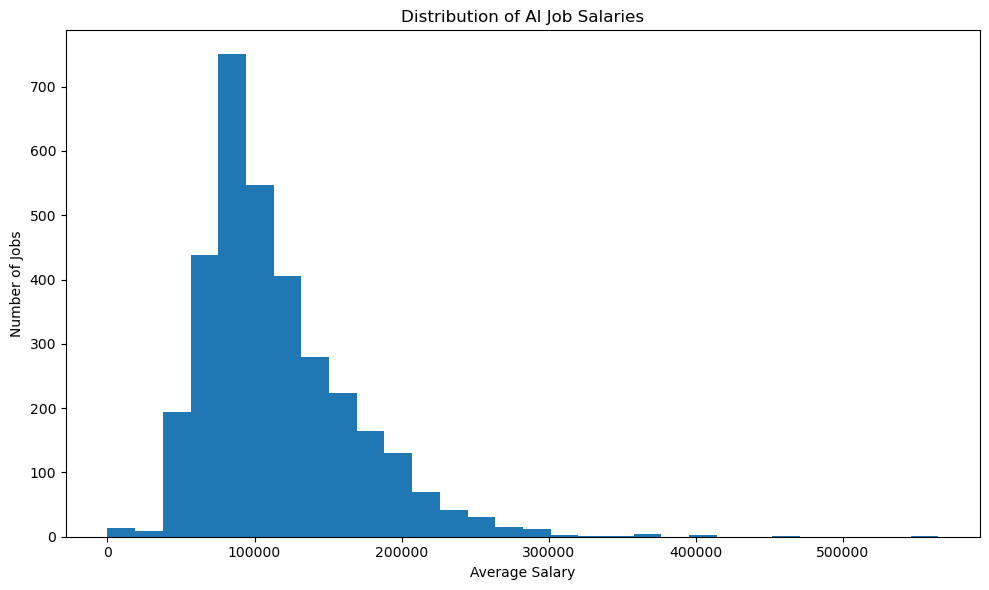

In [93]:
plt.figure(figsize=(10, 6))

plt.hist(
    salary_df["avg_salary"],
    bins=30
)

plt.xlabel("Average Salary")
plt.ylabel("Number of Jobs")
plt.title("Distribution of AI Job Salaries")

plt.tight_layout()
plt.show()

In [94]:
salary_df[
    ["salary_min", "salary_max", "avg_salary"]
].corr()

,salary_min,salary_max,avg_salary
salary_min,1.000000,0.880543,0.962628
salary_max,0.880543,1.000000,0.975999
avg_salary,0.962628,0.975999,1.000000


In [95]:
experience_salary = (
    salary_df
    .groupby("experience_level")["avg_salary"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

experience_salary.columns = [
    "experience_level",
    "avg_salary",
    "median_salary",
    "job_count"
]

experience_salary.sort_values(
    "avg_salary",
    ascending=False
)

,experience_level,avg_salary,median_salary,job_count
4,Senior,131482.706767,122000.0,665
0,Junior,129710.144928,124500.0,138
1,Lead,124068.181818,110500.0,374
2,Management,115423.913043,107750.0,92
3,Mid-level,106811.229429,97000.0,2066


In [97]:
experience_map = {
    "Junior": 1,
    "Mid-level": 2,
    "Senior": 3,
    "Lead": 4,
    "Management": 5
}

salary_df["experience_num"] = (
    salary_df["experience_level"].map(experience_map)
)

In [98]:
salary_df[
    ["experience_level", "experience_num"]
].drop_duplicates().sort_values("experience_num")

,experience_level,experience_num
403,Junior,1
3,Mid-level,2
4,Senior,3
0,Lead,4
164,Management,5


In [99]:
salary_df[
    ["experience_num", "avg_salary"]
].corr()

,experience_num,avg_salary
experience_num,1.000000,0.111708
avg_salary,0.111708,1.000000


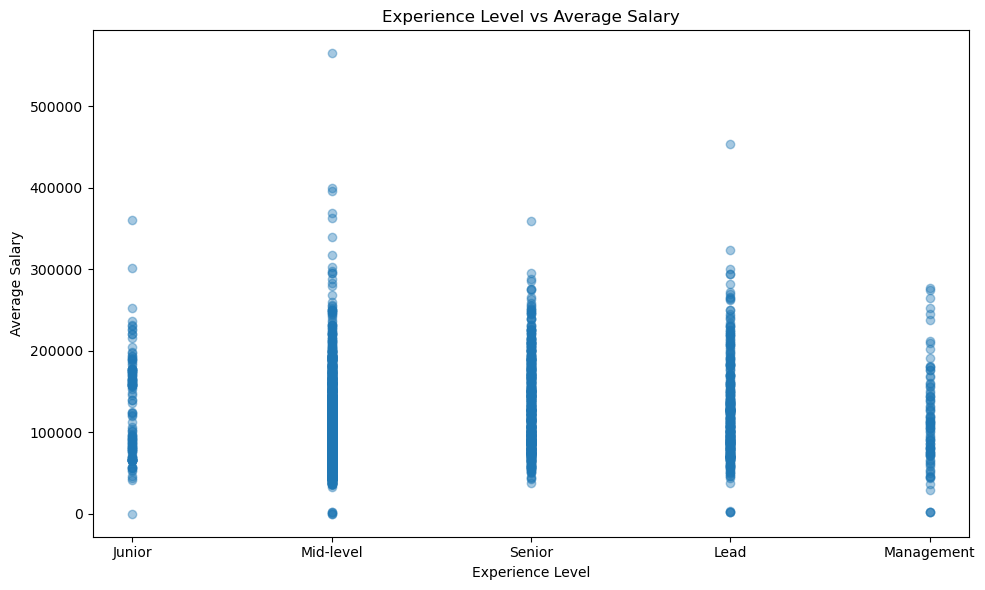

In [100]:
plt.figure(figsize=(10, 6))

plt.scatter(
    salary_df["experience_num"],
    salary_df["avg_salary"],
    alpha=0.4
)

plt.xlabel("Experience Level")
plt.ylabel("Average Salary")
plt.title("Experience Level vs Average Salary")

plt.xticks(
    [1, 2, 3, 4, 5],
    ["Junior", "Mid-level", "Senior", "Lead", "Management"]
)

plt.tight_layout()
plt.show()

In [101]:
salary_df["skill_count"] = (
    salary_df["required_skills"]
    .fillna("")
    .str.split(",")
    .apply(
        lambda x: len([skill for skill in x if skill.strip()])
    )
)

In [102]:
salary_df[
    ["required_skills", "skill_count"]
].head(10)

,required_skills,skill_count
0,RAG,1
1,RAG,1
2,RAG,1
3,<NA>,0
4,<NA>,0
5,"Python, NLP, Computer Vision",3
6,"Python, NLP, Computer Vision",3
7,"Python, NLP, Computer Vision",3
8,"Python, LangChain",2
9,<NA>,0


In [103]:
salary_df[
    ["skill_count", "avg_salary"]
].corr()

,skill_count,avg_salary
skill_count,1.000000,0.004312
avg_salary,0.004312,1.000000


In [104]:
correlation_summary = salary_df[
    [
        "experience_num",
        "skill_count",
        "avg_salary"
    ]
].corr()

correlation_summary

,experience_num,skill_count,avg_salary
experience_num,1.000000,-0.015368,0.111708
skill_count,-0.015368,1.000000,0.004312
avg_salary,0.111708,0.004312,1.000000


In [105]:
salary_df["salary_band"] = pd.qcut(
    salary_df["avg_salary"],
    q=4,
    labels=[
        "Low",
        "Lower-Mid",
        "Upper-Mid",
        "High"
    ]
)

In [106]:
salary_df["salary_band"].value_counts().sort_index()

salary_band
Low          851
Lower-Mid    827
Upper-Mid    829
High         828
Name: count, dtype: int64

In [107]:
band_analysis = (
    salary_df
    .groupby("salary_band", observed=True)
    .agg(
        avg_salary=("avg_salary", "mean"),
        median_salary=("avg_salary", "median"),
        job_count=("avg_salary", "count"),
        avg_skill_count=("skill_count", "mean"),
        avg_experience=("experience_num", "mean")
    )
    .reset_index()
)

band_analysis

,salary_band,avg_salary,median_salary,job_count,avg_skill_count,avg_experience
0,Low,63900.705053,67000.0,851,0.364277,2.394830
1,Lower-Mid,91331.318017,90500.0,827,0.252721,2.383313
2,Upper-Mid,119717.129071,118000.0,829,0.332931,2.501809
3,High,185836.352657,175750.0,828,0.329710,2.582126


In [108]:
experience_band = pd.crosstab(
    salary_df["experience_level"],
    salary_df["salary_band"],
    normalize="columns"
) * 100

experience_band.round(2)

salary_band,Low,Lower-Mid,Upper-Mid,High
experience_level,,,,
Junior,4.58,2.78,1.33,7.85
Lead,9.99,10.04,12.30,12.56
Management,3.41,1.57,2.90,3.14
Mid-level,68.16,69.29,65.26,44.93
Senior,13.87,16.32,18.21,31.52


In [109]:
experience_band = pd.crosstab(
    salary_df["experience_level"],
    salary_df["salary_band"],
    normalize="columns"
) * 100

experience_band.round(2)

salary_band,Low,Lower-Mid,Upper-Mid,High
experience_level,,,,
Junior,4.58,2.78,1.33,7.85
Lead,9.99,10.04,12.30,12.56
Management,3.41,1.57,2.90,3.14
Mid-level,68.16,69.29,65.26,44.93
Senior,13.87,16.32,18.21,31.52


In [110]:
experience_band = pd.crosstab(
    salary_df["experience_level"],
    salary_df["salary_band"],
    normalize="columns"
) * 100

experience_band.round(2)

salary_band,Low,Lower-Mid,Upper-Mid,High
experience_level,,,,
Junior,4.58,2.78,1.33,7.85
Lead,9.99,10.04,12.30,12.56
Management,3.41,1.57,2.90,3.14
Mid-level,68.16,69.29,65.26,44.93
Senior,13.87,16.32,18.21,31.52


In [111]:
salary_df[
    ["required_skills", "skill_count"]
].head(10)

,required_skills,skill_count
0,RAG,1
1,RAG,1
2,RAG,1
3,<NA>,0
4,<NA>,0
5,"Python, NLP, Computer Vision",3
6,"Python, NLP, Computer Vision",3
7,"Python, NLP, Computer Vision",3
8,"Python, LangChain",2
9,<NA>,0


In [112]:
band_analysis = (
    salary_df
    .groupby("salary_band", observed=True)
    .agg(
        avg_salary=("avg_salary", "mean"),
        median_salary=("avg_salary", "median"),
        job_count=("avg_salary", "count"),
        avg_skill_count=("skill_count", "mean"),
        avg_experience=("experience_num", "mean")
    )
    .reset_index()
)

band_analysis

,salary_band,avg_salary,median_salary,job_count,avg_skill_count,avg_experience
0,Low,63900.705053,67000.0,851,0.364277,2.394830
1,Lower-Mid,91331.318017,90500.0,827,0.252721,2.383313
2,Upper-Mid,119717.129071,118000.0,829,0.332931,2.501809
3,High,185836.352657,175750.0,828,0.329710,2.582126


In [113]:
experience_band = pd.crosstab(
    salary_df["experience_level"],
    salary_df["salary_band"],
    normalize="columns"
) * 100

experience_band.round(2)

salary_band,Low,Lower-Mid,Upper-Mid,High
experience_level,,,,
Junior,4.58,2.78,1.33,7.85
Lead,9.99,10.04,12.30,12.56
Management,3.41,1.57,2.90,3.14
Mid-level,68.16,69.29,65.26,44.93
Senior,13.87,16.32,18.21,31.52


In [114]:
salary_df["is_high_band"] = (
    salary_df["salary_band"] == "High"
)

In [115]:
high_vs_rest = (
    salary_df
    .groupby("is_high_band")
    .agg(
        avg_salary=("avg_salary", "mean"),
        avg_skill_count=("skill_count", "mean"),
        avg_experience=("experience_num", "mean"),
        job_count=("avg_salary", "count")
    )
    .reset_index()
)

high_vs_rest

,is_high_band,avg_salary,avg_skill_count,avg_experience,job_count
0,False,91406.461907,0.317112,2.426406,2507
1,True,185836.352657,0.329710,2.582126,828


In [116]:
high_skill_df = salary_df[
    salary_df["salary_band"] == "High"
].copy()

In [117]:
high_skill_df["skill"] = (
    high_skill_df["required_skills"]
    .str.split(",")
)

In [118]:
high_skill_df = high_skill_df.explode("skill")

In [119]:
high_skill_df["skill"] = (
    high_skill_df["skill"]
    .str.strip()
    .str.lower()
)

In [120]:
high_skill_counts = (
    high_skill_df["skill"]
    .value_counts()
    .reset_index()
)

high_skill_counts.columns = [
    "skill",
    "high_band_jobs"
]

In [121]:
high_skill_counts.head(15)

,skill,high_band_jobs
0,computer vision,99
1,python,34
2,nlp,34
3,azure,17
4,r,17
5,sql,15
6,rag,12
7,aws,10
8,transformers,9
9,openai,7


In [122]:
overall_skill_counts = (
    skill_df["skill"]
    .value_counts()
    .reset_index()
)

overall_skill_counts.columns = [
    "skill",
    "overall_jobs"
]

In [123]:
skill_band_comparison = high_skill_counts.merge(
    overall_skill_counts,
    on="skill",
    how="left"
)

In [124]:
skill_band_comparison["high_band_share"] = (
    skill_band_comparison["high_band_jobs"] /
    salary_df[salary_df["salary_band"] == "High"].shape[0]
) * 100

In [125]:
skill_band_comparison["overall_share"] = (
    skill_band_comparison["overall_jobs"] /
    salary_df.shape[0]
) * 100

In [126]:
skill_band_comparison["share_difference"] = (
    skill_band_comparison["high_band_share"] -
    skill_band_comparison["overall_share"]
)

In [127]:
skill_band_comparison.sort_values(
    "share_difference",
    ascending=False
).head(15)

,skill,high_band_jobs,overall_jobs,high_band_share,overall_share,share_difference
0,computer vision,99,221,11.956522,6.626687,5.329835
8,transformers,9,11,1.086957,0.329835,0.757121
4,r,17,53,2.053140,1.589205,0.463935
10,langchain,5,11,0.603865,0.329835,0.274030
13,kubernetes,2,9,0.241546,0.269865,-0.028319
11,gcp,4,18,0.483092,0.539730,-0.056638
14,spark,2,12,0.241546,0.359820,-0.118274
5,sql,15,65,1.811594,1.949025,-0.137431
2,nlp,34,143,4.106280,4.287856,-0.181576
15,pytorch,2,15,0.241546,0.449775,-0.208229


In [128]:
high_role_analysis = (
    salary_df[
        salary_df["salary_band"] == "High"
    ]
    .groupby("job_title")
    .size()
    .reset_index(name="high_band_jobs")
    .sort_values(
        "high_band_jobs",
        ascending=False
    )
)

high_role_analysis.head(15)

,job_title,high_band_jobs
117,Data Scientist,52
6,AI Engineer,44
26,"AI Research Engineer (Junior career, Hybrid, G...",39
386,Senior SaaS Cloud Capacity Engineer,29
40,"AI Research Software Engineer Senior (hybrid, ...",25
124,Data Scientist with Security Clearance,15
42,AI Researcher,9
321,Senior Computer Vision Engineer,7
328,Senior Data Scientist,7
211,Lead AI Engineer,7


In [129]:
high_country_analysis = (
    salary_df[
        salary_df["salary_band"] == "High"
    ]
    .groupby("country")
    .size()
    .reset_index(name="high_band_jobs")
    .sort_values(
        "high_band_jobs",
        ascending=False
    )
)

high_country_analysis.head(15)

,country,high_band_jobs
4,United States,686
3,United Kingdom,92
1,Canada,29
2,Germany,11
0,Australia,10


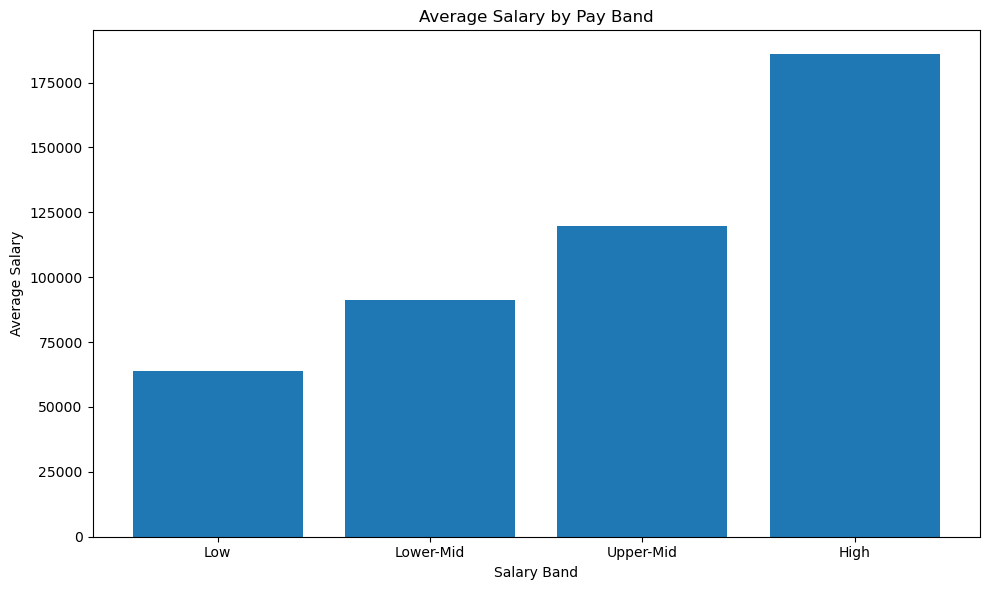

In [130]:
plt.figure(figsize=(10, 6))

plt.bar(
    band_analysis["salary_band"],
    band_analysis["avg_salary"]
)

plt.xlabel("Salary Band")
plt.ylabel("Average Salary")
plt.title("Average Salary by Pay Band")

plt.tight_layout()
plt.show()

In [131]:
da_summary = pd.DataFrame({
    "Metric": [
        "Overall Average Salary",
        "High Band Average Salary",
        "High Band Median Salary",
        "High Band Average Experience",
        "Overall Average Experience",
        "High Band Average Skill Count",
        "Overall Average Skill Count"
    ],
    "Value": [
        salary_df["avg_salary"].mean(),
        salary_df.loc[
            salary_df["salary_band"] == "High",
            "avg_salary"
        ].mean(),
        salary_df.loc[
            salary_df["salary_band"] == "High",
            "avg_salary"
        ].median(),
        salary_df.loc[
            salary_df["salary_band"] == "High",
            "experience_num"
        ].mean(),
        salary_df["experience_num"].mean(),
        salary_df.loc[
            salary_df["salary_band"] == "High",
            "skill_count"
        ].mean(),
        salary_df["skill_count"].mean()
    ]
})

da_summary

,Metric,Value
0,Overall Average Salary,114851.124438
1,High Band Average Salary,185836.352657
2,High Band Median Salary,175750.000000
3,High Band Average Experience,2.582126
4,Overall Average Experience,2.465067
5,High Band Average Skill Count,0.329710
6,Overall Average Skill Count,0.320240


In [132]:
model_df = salary_df[
    [
        "avg_salary",
        "experience_level",
        "skill_count",
        "remote_type",
        "country",
        "job_title"
    ]
].copy()

In [133]:
model_df = model_df.dropna(
    subset=["avg_salary"]
)

In [134]:
X = model_df.drop(
    columns=["avg_salary"]
)

y = model_df["avg_salary"]

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [136]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [137]:
numeric_features = [
    "skill_count"
]

categorical_features = [
    "experience_level",
    "remote_type",
    "country",
    "job_title"
]

In [138]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [139]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [140]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                max_depth=10
            )
        )
    ]
)

In [141]:
model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [142]:
y_pred = model.predict(X_test)

In [143]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 28202.59253847267
RMSE: 41216.926036302415
R²: 0.3798354565529507


In [144]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [145]:
importances = (
    model
    .named_steps["regressor"]
    .feature_importances_
)

In [146]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [147]:
feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

In [148]:
feature_importance.head(20)

,feature,importance
14,cat__country_United States,0.258326
4,cat__experience_level_Mid-level,0.212009
694,cat__job_title_Machine Learning Operations (ML...,0.054067
835,cat__job_title_Research Engineer - Pretraining,0.051535
654,cat__job_title_Machine Learning Engineer (PhD ...,0.042993
1156,"cat__job_title_Staff Software Engineer, Inference",0.032671
337,cat__job_title_Corporate Finance / Investment ...,0.025024
836,"cat__job_title_Research Engineer / Scientist, ...",0.024271
1106,"cat__job_title_Software Engineer, Safeguards I...",0.019078
120,cat__job_title_AI Researcher,0.017007


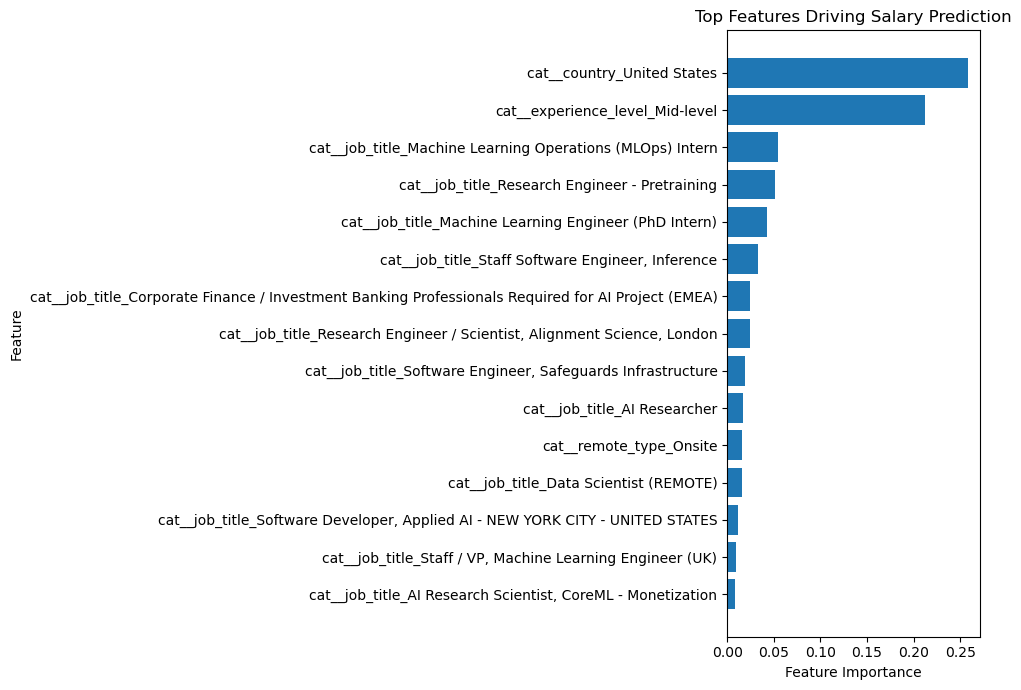

In [149]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features Driving Salary Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

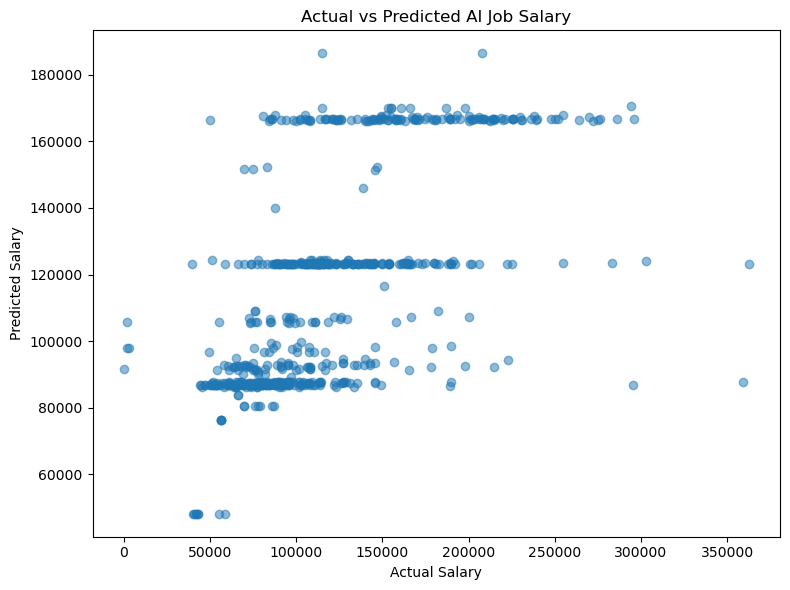

In [150]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted AI Job Salary")

plt.tight_layout()
plt.show()

In [151]:
prediction_results = pd.DataFrame({
    "actual_salary": y_test.values,
    "predicted_salary": y_pred
})

prediction_results["error"] = (
    prediction_results["actual_salary"] -
    prediction_results["predicted_salary"]
)

prediction_results.head(10)

,actual_salary,predicted_salary,error
0,79000.0,87636.365308,-8636.365308
1,78000.0,90600.827660,-12600.827660
2,94000.0,86852.144716,7147.855284
3,110500.0,96669.820932,13830.179068
4,110000.0,123406.005340,-13406.005340
5,85000.0,86852.144716,-1852.144716
6,88000.0,123165.169103,-35165.169103
7,170500.0,166369.328832,4130.671168
8,169000.0,166712.821048,2287.178952
9,75000.0,87336.488308,-12336.488308


In [152]:
classification_df = salary_df[
    [
        "salary_band",
        "experience_level",
        "skill_count",
        "remote_type",
        "country",
        "job_title"
    ]
].dropna(
    subset=["salary_band"]
).copy()

In [153]:
classification_df["high_salary"] = (
    classification_df["salary_band"] == "High"
).astype(int)

In [154]:
X = classification_df[
    [
        "experience_level",
        "skill_count",
        "remote_type",
        "country",
        "job_title"
    ]
]

y = classification_df["high_salary"]

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [156]:
from sklearn.ensemble import RandomForestClassifier

classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=10
            )
        )
    ]
)

In [157]:
classifier.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [158]:
y_pred_class = classifier.predict(X_test)

In [159]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_class)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_class)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_class)
)

print(
    "F1:",
    f1_score(y_test, y_pred_class)
)

Accuracy: 0.7691154422788605
Precision: 0.9285714285714286
Recall: 0.0783132530120482
F1: 0.14444444444444443


In [160]:
print(
    classification_report(
        y_test,
        y_pred_class
    )
)

              precision    recall  f1-score   support

           0       0.77      1.00      0.87       501
           1       0.93      0.08      0.14       166

    accuracy                           0.77       667
   macro avg       0.85      0.54      0.51       667
weighted avg       0.81      0.77      0.69       667



In [162]:
print(len(feature_names))
print(len(classifier.named_steps["classifier"].feature_importances_))

1208
1217


In [163]:
feature_names = classifier.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))
print(len(classifier.named_steps["classifier"].feature_importances_))

1217
1217


In [164]:
classifier_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": classifier.named_steps["classifier"].feature_importances_
})

classifier_importance = classifier_importance.sort_values(
    "importance",
    ascending=False
)

classifier_importance.head(20)

,feature,importance
14,cat__country_United States,0.142170
13,cat__country_United Kingdom,0.091204
102,cat__job_title_AI Research Engineer (Junior ca...,0.061763
1042,cat__job_title_Senior SaaS Cloud Capacity Engi...,0.055004
4,cat__experience_level_Mid-level,0.052348
125,cat__job_title_AI Research Software Engineer S...,0.042720
5,cat__experience_level_Senior,0.040364
658,cat__job_title_Machine Learning Engineer (PhD ...,0.036190
7,cat__remote_type_Onsite,0.025945
1,cat__experience_level_Junior,0.020732


In [165]:
dashboard_df = salary_df[
    [
        "job_title",
        "company",
        "country",
        "city",
        "salary_min",
        "salary_max",
        "avg_salary",
        "currency",
        "remote_type",
        "experience_level",
        "required_skills",
        "posted_date",
        "source",
        "skill_count",
        "salary_band"
    ]
].copy()

In [166]:
dashboard_df.to_csv(
    "ai_jobs_dashboard.csv",
    index=False
)

In [167]:
import os

"ai_jobs_dashboard.csv" in os.listdir()

True